A Business Analytics Model On a Dataset using the Random Forest Classifier

In [51]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder,  StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

IMPORTING THE DATASET 

In [52]:
df = pd.read_csv('SampleSuperstore.csv')


DATA OVERVIEW AND DESCRIPTION

In [53]:
print(df.isnull().sum()) #identifying missing values


Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


In [54]:
df. head(5)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [55]:
df.tail(5)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.248,3,0.2,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.960,2,0.0,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.576,2,0.2,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.600,4,0.0,13.3200
9993,Second Class,Consumer,United States,Westminster,California,92683,West,Office Supplies,Appliances,243.160,2,0.0,72.9480


In [56]:
df['Ship Mode'].unique()

array(['Second Class', 'Standard Class', 'First Class', 'Same Day'],
      dtype=object)

In [57]:
df['Category'].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

DATA PREPARATION STEPS


In [58]:
# Drop Customer_ID as it is not useful for modeling
df= df.drop(columns=['Postal Code'])

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Region        9994 non-null   object 
 6   Category      9994 non-null   object 
 7   Sub-Category  9994 non-null   object 
 8   Sales         9994 non-null   float64
 9   Quantity      9994 non-null   int64  
 10  Discount      9994 non-null   float64
 11  Profit        9994 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 937.1+ KB


In [42]:
df['Discount'].unique()


array([0.  , 0.45, 0.2 , 0.8 , 0.3 , 0.5 , 0.7 , 0.6 , 0.32, 0.1 , 0.4 ,
       0.15])

In [43]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976


In [61]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in ['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Region', 'Category', 'Profit', 'Sub-Category']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Save the encoder for decoding later


DATA TRANSFORMATION

In [45]:
#Scale numerical features
scaler = StandardScaler()
df[['Sales','Quantity', 'Category', 'Sub-Category','Ship Mode', 'Country', 'Region', 'State', 'City','Segment', 'Discount']] = scaler.fit_transform(df[['Sales','Quantity', 'Category', 'Sub-Category','Ship Mode', 'Country', 'Region', 'State', 'City','Segment', 'Discount']])

In [59]:
print("Profit unique values:", df["Profit"].unique())
print("Sub-Category unique values:", df["Sub-Category"].unique())
print("Category unique values:", df["Category"].unique())


Profit unique values: [ 41.9136 219.582    6.8714 ...  16.124    4.1028  72.948 ]
Sub-Category unique values: ['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']
Category unique values: ['Furniture' 'Office Supplies' 'Technology']


Correlation Matrix (Raw):
               Ship Mode   Segment  Country      City     State    Region  \
Ship Mode      1.000000 -0.004527      NaN -0.003602  0.011865 -0.023809   
Segment       -0.004527  1.000000      NaN  0.005505 -0.002567 -0.005560   
Country             NaN       NaN      NaN       NaN       NaN       NaN   
City          -0.003602  0.005505      NaN  1.000000  0.009805  0.282255   
State          0.011865 -0.002567      NaN  0.009805  1.000000 -0.444400   
Region        -0.023809 -0.005560      NaN  0.282255 -0.444400  1.000000   
Category      -0.004129  0.010123      NaN  0.013736  0.006285 -0.005148   
Sub-Category  -0.003275  0.010943      NaN -0.005966 -0.002061  0.009112   
Sales         -0.001887  0.010866      NaN  0.005592  0.004015  0.004216   
Quantity       0.022440  0.008130      NaN -0.000929 -0.000836  0.013506   
Discount      -0.000436 -0.016679      NaN -0.151914  0.162552 -0.212769   
Profit        -0.010696  0.021213      NaN  0.089008 -0.11795

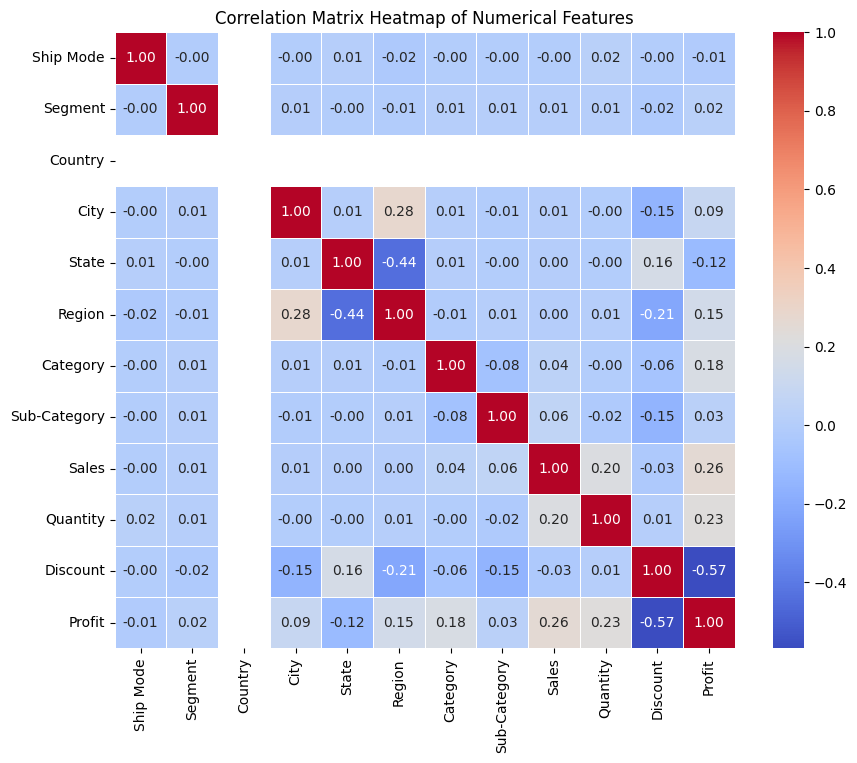

In [62]:
numerical_df = df.select_dtypes(include=np.number)

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Print the correlation matrix
print("Correlation Matrix (Raw):\n", correlation_matrix)

plt.figure(figsize=(10, 8)) # Adjust size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix Heatmap of Numerical Features')
plt.show()

C:\Users\Sparkhiee\AppData\Local\Temp\ipykernel_19764\1499227168.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Sales', data=sales_by_category, palette='viridis')


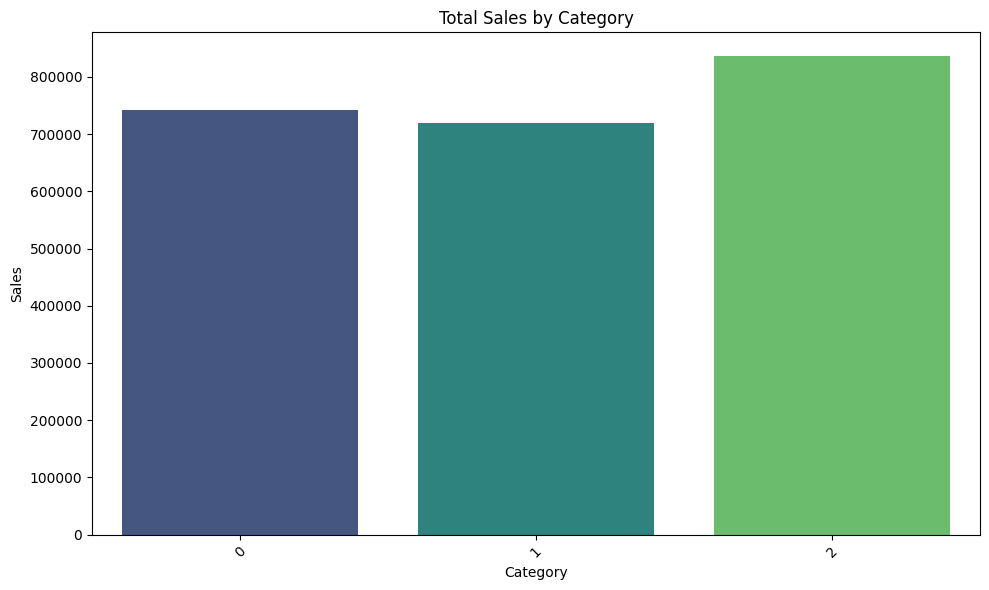

In [63]:
sales_by_category = df.groupby('Category')['Sales'].sum().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Sales', data=sales_by_category, palette='viridis')
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

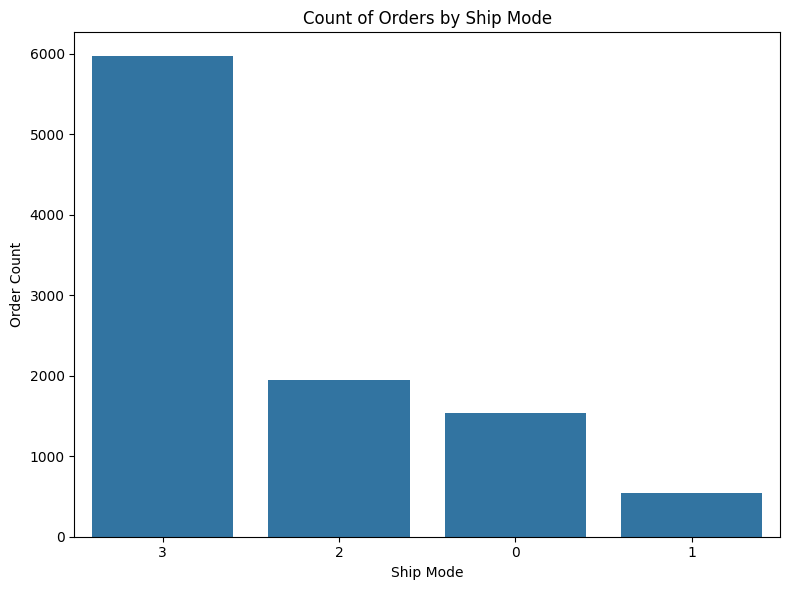

In [64]:
# Count Plot for 'Ship Mode'
plt.figure(figsize=(8, 6))
sns.countplot(x='Ship Mode', data=df, order=df['Ship Mode'].value_counts().index)
plt.title("Count of Orders by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Order Count")
plt.tight_layout()
plt.show()

Text(0.5, 0, 'Sales')

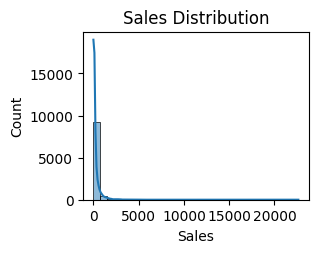

In [65]:
# Sales Distribution
plt.subplot(2, 2, 1)
sns.histplot(df['Sales'], bins=30, kde=True)
plt.title('Sales Distribution')
plt.xlabel('Sales')

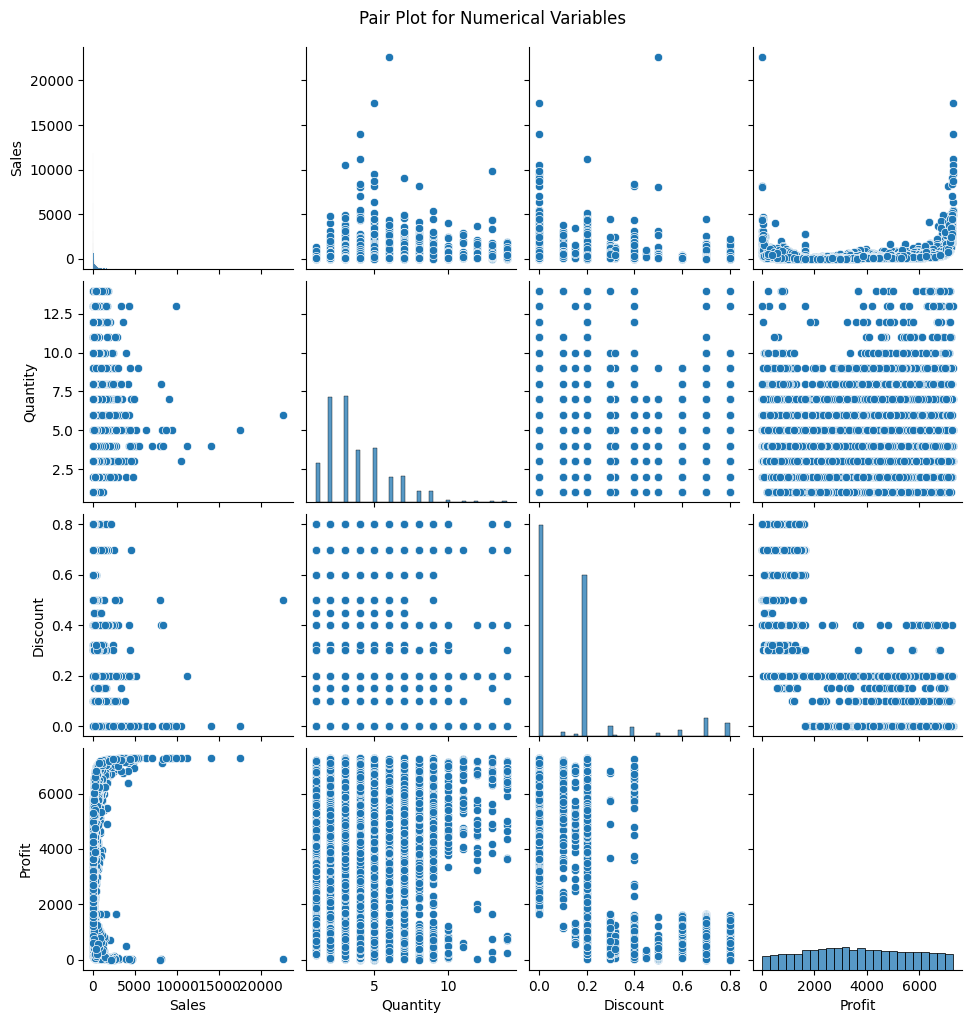

In [66]:
sns.pairplot(df[['Sales', 'Quantity', 'Discount', 'Profit']])
plt.suptitle("Pair Plot for Numerical Variables", y=1.02)
plt.show()

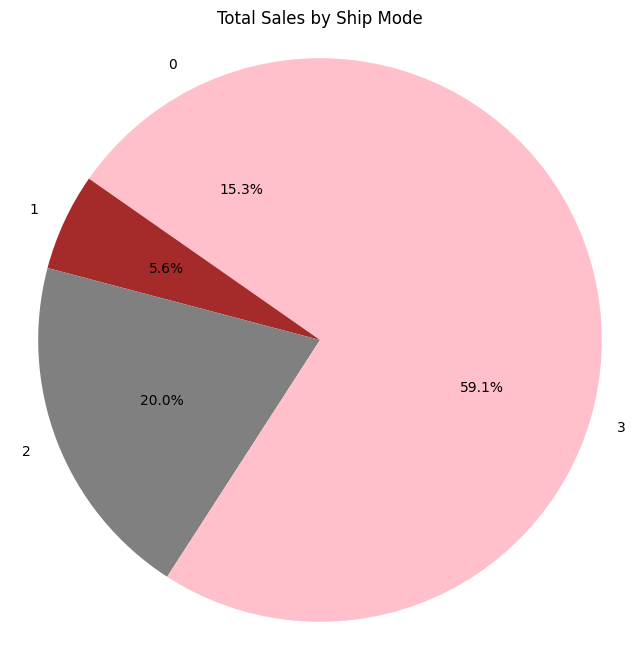

In [74]:
sales_by_ship_mode = df.groupby("Ship Mode")["Sales"].sum()

# --- 3. Create the Pie Chart ---
plt.figure(figsize=(8, 8))
plt.pie(sales_by_ship_mode,
        labels=sales_by_ship_mode.index,
        autopct='%1.1f%%',   # Display percentages with one decimal place
        startangle=90,       # Rotate pie start angle for better view
        colors= ['pink','brown','grey'])  # Optional: set a colormap

plt.title("Total Sales by Ship Mode")
plt.axis("equal")  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [75]:
df.to_csv('business_analytics_model_Superstore EDA.csv', index=False)